In [1]:
import os

DATASET_PATH = "/kaggle/input"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    print("Dirs:", dirs[:5])
    print("Files:", files[:10])
    print("-" * 60)

/kaggle/input
Dirs: ['datasets']
Files: []
------------------------------------------------------------
/kaggle/input/datasets
Dirs: ['alamson']
Files: []
------------------------------------------------------------
/kaggle/input/datasets/alamson
Dirs: ['safebooru']
Files: []
------------------------------------------------------------
/kaggle/input/datasets/alamson/safebooru
Dirs: []
Files: ['all_data.csv']
------------------------------------------------------------


In [2]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/alamson/safebooru/all_data.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (3020460, 9)

Columns:
['id', 'created_at', 'rating', 'score', 'sample_url', 'sample_width', 'sample_height', 'preview_url', 'tags']

First 5 rows:


,id,created_at,rating,score,sample_url,sample_width,sample_height,preview_url,tags
0,1,1264803292,s,37,//safebooru.org/samples/1/sample_e7b3dc281d431...,850,638,//safebooru.org/thumbnails/1/thumbnail_e7b3dc2...,1girl bag black_hair blush bob_cut bowieknife ...
1,2,1264803292,s,12,//safebooru.org/samples/1/sample_27ff11b17a2c3...,850,1208,//safebooru.org/thumbnails/1/thumbnail_27ff11b...,barding black cape celty_sturluson dress dulla...
2,3,1264803298,s,8,//safebooru.org/samples/1/sample_ebd16eb1d1547...,850,599,//safebooru.org/thumbnails/1/thumbnail_ebd16eb...,blue_eyes blush brown_hair original scan takoy...
3,4,1264803299,s,5,//safebooru.org/samples/1/sample_6fbb9a4b9099e...,850,519,//safebooru.org/thumbnails/1/thumbnail_6fbb9a4...,game_cg hagall_valkyr mecha_musume shirogane_n...
4,6,1264803304,s,11,//safebooru.org/samples/1/sample_113cb63dc5412...,850,601,//safebooru.org/thumbnails/1/thumbnail_113cb63...,blush idolmaster kisaragi_chihaya komi_zumiko ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3020460 entries, 0 to 3020459
Data columns (total 9 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   id             int64 
 1   created_at     int64 
 2   rating         object
 3   score          int64 
 4   sample_url     object
 5   sample_width   int64 
 6   sample_height  int64 
 7   preview_url    object
 8   tags           object
dtypes: int64(5), object(4)
memory usage: 207.4+ MB


In [4]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/alamson/safebooru/all_data.csv"
df = pd.read_csv(CSV_PATH)

# Basic cleaning
df = df.dropna(subset=["sample_url", "tags"])

# Convert tags to string
df["tags"] = df["tags"].astype(str)

# Keep only safe-rated images
df = df[df["rating"] == "s"]

# Full-body-ish clean subset
required_tags = ["solo", "1girl", "full_body"]

for tag in required_tags:
    df = df[df["tags"].str.contains(rf"\b{tag}\b", regex=True)]

print("Filtered shape:", df.shape)
display(df.head())

Filtered shape: (107537, 9)


,id,created_at,rating,score,sample_url,sample_width,sample_height,preview_url,tags
119644,123972,1267530482,s,0,//safebooru.org/images/124/693d34d28c2fd6ddcff...,580,1000,//safebooru.org/thumbnails/124/thumbnail_693d3...,1girl aqua_eyes armpits blonde_hair bow detach...
125580,130062,1267544148,s,5,//safebooru.org/images/130/9e8ca85f73d0ab19644...,700,783,//safebooru.org/thumbnails/130/thumbnail_9e8ca...,1girl adult bad_id blonde_hair bottle colorful...
137153,141954,1267567737,s,1,//safebooru.org/images/142/2c1bc85f51532063d65...,480,600,//safebooru.org/thumbnails/142/thumbnail_2c1bc...,1girl full_body kagamine_rin mono_(recall) mus...
371676,386353,1273923461,s,3,//safebooru.org/images/386/ced1f4aa364a1808f6c...,746,2216,//safebooru.org/thumbnails/386/thumbnail_ced1f...,1girl :d alpha alpha_(artist) artist_request b...
402267,417239,1274575863,s,0,//safebooru.org/samples/417/sample_c1467fb0b18...,850,1245,//safebooru.org/thumbnails/417/thumbnail_c1467...,1girl absurdres androgynous bags_under_eyes bl...


In [5]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/alamson/safebooru/all_data.csv"
df = pd.read_csv(CSV_PATH)

# Basic cleaning
df = df.dropna(subset=["sample_url", "tags"])

# Convert tags to string
df["tags"] = df["tags"].astype(str)

# Keep only safe-rated images
df = df[df["rating"] == "s"]

# Full-body-ish clean subset
required_tags = ["solo", "1girl", "full_body"]

for tag in required_tags:
    df = df[df["tags"].str.contains(rf"\b{tag}\b", regex=True)]

print("Filtered shape:", df.shape)
display(df.head())

Filtered shape: (107537, 9)


,id,created_at,rating,score,sample_url,sample_width,sample_height,preview_url,tags
119644,123972,1267530482,s,0,//safebooru.org/images/124/693d34d28c2fd6ddcff...,580,1000,//safebooru.org/thumbnails/124/thumbnail_693d3...,1girl aqua_eyes armpits blonde_hair bow detach...
125580,130062,1267544148,s,5,//safebooru.org/images/130/9e8ca85f73d0ab19644...,700,783,//safebooru.org/thumbnails/130/thumbnail_9e8ca...,1girl adult bad_id blonde_hair bottle colorful...
137153,141954,1267567737,s,1,//safebooru.org/images/142/2c1bc85f51532063d65...,480,600,//safebooru.org/thumbnails/142/thumbnail_2c1bc...,1girl full_body kagamine_rin mono_(recall) mus...
371676,386353,1273923461,s,3,//safebooru.org/images/386/ced1f4aa364a1808f6c...,746,2216,//safebooru.org/thumbnails/386/thumbnail_ced1f...,1girl :d alpha alpha_(artist) artist_request b...
402267,417239,1274575863,s,0,//safebooru.org/samples/417/sample_c1467fb0b18...,850,1245,//safebooru.org/thumbnails/417/thumbnail_c1467...,1girl absurdres androgynous bags_under_eyes bl...


In [6]:
hair_labels = [
    "black_hair",
    "blonde_hair",
    "brown_hair",
    "blue_hair",
    "pink_hair",
    "white_hair"
]

for label in hair_labels:
    count = df["tags"].str.contains(rf"\b{label}\b", regex=True).sum()
    print(label, ":", count)

black_hair : 14202
blonde_hair : 19031
brown_hair : 17435
blue_hair : 8774
pink_hair : 7497
white_hair : 5422


In [7]:
samples_per_class = 500

subset_list = []

for label in hair_labels:
    temp = df[df["tags"].str.contains(rf"\b{label}\b", regex=True)].copy()
    temp["label"] = label
    
    if len(temp) > samples_per_class:
        temp = temp.sample(samples_per_class, random_state=42)
    
    subset_list.append(temp)

subset_df = pd.concat(subset_list).reset_index(drop=True)

print("Final subset shape:", subset_df.shape)
print(subset_df["label"].value_counts())

display(subset_df[["id", "sample_url", "label", "tags"]].head())

Final subset shape: (3000, 10)
label
black_hair     500
blonde_hair    500
brown_hair     500
blue_hair      500
pink_hair      500
white_hair     500
Name: count, dtype: int64


,id,sample_url,label,tags
0,2310502,//safebooru.org/images/2217/294ef4801fa5c3590a...,black_hair,1girl arrow azutarou black_hair black_legwear ...
1,2918523,https://safebooru.org/samples/2802/sample_e606...,black_hair,1girl bangs black_eyes black_hair bulletproof_...
2,2629440,https://safebooru.org/samples/2522/sample_450f...,black_hair,1girl absurdres alternate_costume azur_lane ba...
3,2796082,https://safebooru.org/images/2685/5c5b90ab3fe5...,black_hair,1girl :d animal_ears animal_hat bangs black_bo...
4,2628714,https://safebooru.org/images/2521/794f9712710e...,black_hair,1girl batta_(ijigen_debris) black_eyes black_h...


In [8]:
def fix_url(url):
    url = str(url)
    if url.startswith("//"):
        return "https:" + url
    elif url.startswith("http"):
        return url
    else:
        return "https://" + url

subset_df["image_url"] = subset_df["sample_url"].apply(fix_url)

display(subset_df[["id", "image_url", "label"]].head(10))

,id,image_url,label
0,2310502,https://safebooru.org/images/2217/294ef4801fa5...,black_hair
1,2918523,https://safebooru.org/samples/2802/sample_e606...,black_hair
2,2629440,https://safebooru.org/samples/2522/sample_450f...,black_hair
3,2796082,https://safebooru.org/images/2685/5c5b90ab3fe5...,black_hair
4,2628714,https://safebooru.org/images/2521/794f9712710e...,black_hair
5,1374164,https://safebooru.org/samples/1321/sample_ae2a...,black_hair
6,1928723,https://safebooru.org/images/1846/b61645c30354...,black_hair
7,1840860,https://safebooru.org/samples/1759/sample_c4c5...,black_hair
8,2374824,https://safebooru.org/images/2280/d089bcc519e1...,black_hair
9,2450571,https://safebooru.org/samples/2353/sample_c85c...,black_hair


In [9]:
subset_df[["id", "image_url", "label", "tags"]].to_csv(
    "safebooru_filtered_metadata.csv",
    index=False
)

print("Saved safebooru_filtered_metadata.csv")

Saved safebooru_filtered_metadata.csv


In [10]:
test_subset_df = subset_df.groupby("label").head(500).reset_index(drop=True)

print(test_subset_df["label"].value_counts())
print("Total test images:", len(test_subset_df))

label
black_hair     500
blonde_hair    500
brown_hair     500
blue_hair      500
pink_hair      500
white_hair     500
Name: count, dtype: int64
Total test images: 3000


In [11]:
import os
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm

SAVE_DIR = "safebooru_subset/images"
os.makedirs(SAVE_DIR, exist_ok=True)

records = []

for idx, row in tqdm(test_subset_df.iterrows(), total=len(test_subset_df)):
    image_id = row["id"]
    url = row["image_url"]
    label = row["label"]
    
    try:
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            img = Image.open(BytesIO(response.content)).convert("RGB")
            img = img.resize((64, 64))
            
            filename = f"{image_id}.jpg"
            save_path = os.path.join(SAVE_DIR, filename)
            img.save(save_path, "JPEG")
            
            records.append({
                "image_path": save_path,
                "label": label
            })
            
    except Exception as e:
        pass

labels_df = pd.DataFrame(records)
labels_df.to_csv("safebooru_subset/labels.csv", index=False)

print("Downloaded images:", len(labels_df))
print(labels_df["label"].value_counts())
display(labels_df.head())

  6%|▌         | 172/3000 [00:21<05:08,  9.16it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 3000/3000 [06:16<00:00,  7.97it/s]

Downloaded images: 2448
label
brown_hair     429
white_hair     409
blonde_hair    404
black_hair     402
blue_hair      402
pink_hair      402
Name: count, dtype: int64


,image_path,label
0,safebooru_subset/images/2310502.jpg,black_hair
1,safebooru_subset/images/2918523.jpg,black_hair
2,safebooru_subset/images/2796082.jpg,black_hair
3,safebooru_subset/images/2628714.jpg,black_hair
4,safebooru_subset/images/1374164.jpg,black_hair


In [12]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

labels_df = pd.read_csv("safebooru_subset/labels.csv")

label_to_idx = {label: idx for idx, label in enumerate(sorted(labels_df["label"].unique()))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(label_to_idx)

{'black_hair': 0, 'blonde_hair': 1, 'blue_hair': 2, 'brown_hair': 3, 'pink_hair': 4, 'white_hair': 5}


In [13]:
class SafeBooruDataset(Dataset):
    def __init__(self, csv_file, transform=None, label_to_idx=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]["image_path"]
        label_name = self.data.iloc[idx]["label"]
        label = self.label_to_idx[label_name]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = SafeBooruDataset(
    csv_file="safebooru_subset/labels.csv",
    transform=transform,
    label_to_idx=label_to_idx
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

images, labels = next(iter(dataloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])
Sample labels: tensor([5, 1, 3, 4, 5, 0, 4, 0, 3, 1])


In [15]:
import os

BASE_DIR = "/kaggle/working/week5_safebooru"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/datasets/safebooru_subset", exist_ok=True)
os.makedirs(f"{BASE_DIR}/results/conditional_gan_safebooru", exist_ok=True)

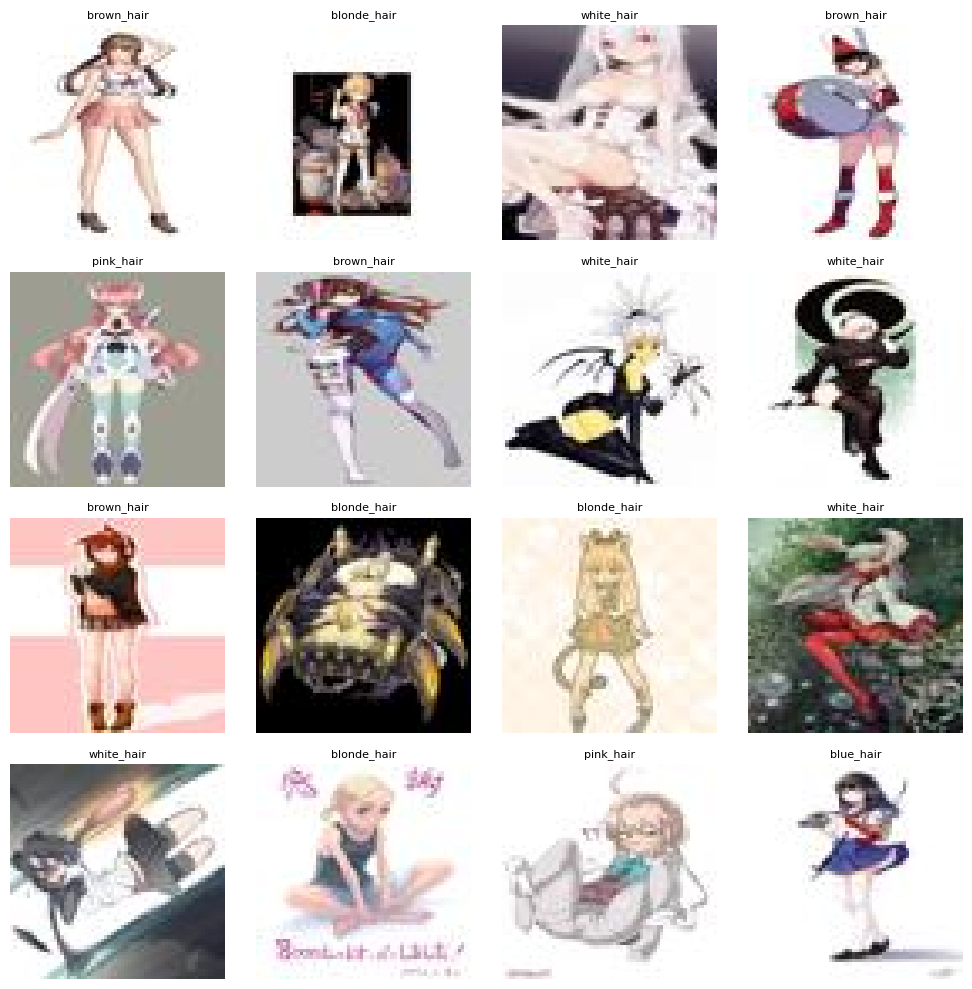

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img * 0.5 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

batch_images, batch_labels = next(iter(dataloader))

plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    imshow(batch_images[i])
    plt.title(idx_to_label[batch_labels[i].item()], fontsize=8)
plt.tight_layout()

plt.savefig(
    f"{BASE_DIR}/results/conditional_gan_safebooru/week5_sample_batch.png",
    dpi=200
)

plt.show()

In [17]:
labels_df.to_csv(
    f"{BASE_DIR}/datasets/safebooru_subset/labels.csv",
    index=False
)

subset_df[["id", "image_url", "label", "tags"]].to_csv(
    f"{BASE_DIR}/datasets/safebooru_subset/safebooru_filtered_metadata.csv",
    index=False
)

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

OUTPUT_DIR = "/kaggle/working/week6_cgan_safebooru"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/samples", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)

Using device: cuda


In [19]:
image_size = 64
channels = 3
latent_dim = 100
num_classes = len(label_to_idx)
embedding_dim = 100

batch_size = 32
lr = 0.0002
beta1 = 0.5
num_epochs = 30

print("Number of classes:", num_classes)
print("Labels:", label_to_idx)

Number of classes: 6
Labels: {'black_hair': 0, 'blonde_hair': 1, 'blue_hair': 2, 'brown_hair': 3, 'pink_hair': 4, 'white_hair': 5}


In [20]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, embedding_dim, channels):
        super(ConditionalGenerator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, embedding_dim)

        self.model = nn.Sequential(
            # input: latent_dim + embedding_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim + embedding_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 4x4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8x8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16x16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([noise, label_embedding], dim=1)
        x = x.unsqueeze(2).unsqueeze(3)
        return self.model(x)

In [21]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes, image_size, channels):
        super(ConditionalDiscriminator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, image_size * image_size)

        self.model = nn.Sequential(
            # input: image channels + 1 label channel
            nn.Conv2d(channels + 1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, images, labels):
        label_embedding = self.label_emb(labels)
        label_embedding = label_embedding.view(labels.size(0), 1, image_size, image_size)

        x = torch.cat([images, label_embedding], dim=1)
        return self.model(x).view(-1)

In [22]:
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator = ConditionalGenerator(
    latent_dim=latent_dim,
    num_classes=num_classes,
    embedding_dim=embedding_dim,
    channels=channels
).to(device)

discriminator = ConditionalDiscriminator(
    num_classes=num_classes,
    image_size=image_size,
    channels=channels
).to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

print(generator)
print(discriminator)

ConditionalGenerator(
  (label_emb): Embedding(6, 100)
  (model): Sequential(
    (0): ConvTranspose2d(200, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), paddin

In [23]:
samples_per_class = 8

fixed_labels = []
for class_idx in range(num_classes):
    fixed_labels += [class_idx] * samples_per_class

fixed_labels = torch.tensor(fixed_labels, dtype=torch.long).to(device)
fixed_noise = torch.randn(len(fixed_labels), latent_dim).to(device)

print("Fixed noise:", fixed_noise.shape)
print("Fixed labels:", fixed_labels.shape)

Fixed noise: torch.Size([48, 100])
Fixed labels: torch.Size([48])


In [24]:
def save_generated_samples(epoch):
    generator.eval()

    with torch.no_grad():
        fake_images = generator(fixed_noise, fixed_labels)
        fake_images = fake_images * 0.5 + 0.5

        grid = make_grid(fake_images, nrow=samples_per_class)

        save_path = f"{OUTPUT_DIR}/samples/epoch_{epoch:03d}.png"
        save_image(grid, save_path)

    generator.train()
    print("Saved:", save_path)

In [25]:
G_losses = []
D_losses = []

real_label = 1.0
fake_label = 0.0

for epoch in range(1, num_epochs + 1):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for batch_idx, (real_images, labels) in enumerate(dataloader):
        real_images = real_images.to(device)
        labels = labels.to(device)

        current_batch_size = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------
        discriminator.zero_grad()

        real_targets = torch.full((current_batch_size,), real_label, dtype=torch.float, device=device)
        fake_targets = torch.full((current_batch_size,), fake_label, dtype=torch.float, device=device)

        output_real = discriminator(real_images, labels)
        loss_D_real = criterion(output_real, real_targets)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = generator(noise, labels)

        output_fake = discriminator(fake_images.detach(), labels)
        loss_D_fake = criterion(output_fake, fake_targets)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        generator.zero_grad()

        output_fake_for_G = discriminator(fake_images, labels)
        loss_G = criterion(output_fake_for_G, real_targets)

        loss_G.backward()
        optimizer_G.step()

        epoch_D_loss += loss_D.item()
        epoch_G_loss += loss_G.item()

    avg_D_loss = epoch_D_loss / len(dataloader)
    avg_G_loss = epoch_G_loss / len(dataloader)

    D_losses.append(avg_D_loss)
    G_losses.append(avg_G_loss)

    print(
        f"Epoch [{epoch}/{num_epochs}] "
        f"D Loss: {avg_D_loss:.4f} "
        f"G Loss: {avg_G_loss:.4f}"
    )

    if epoch == 1 or epoch % 5 == 0 or epoch == num_epochs:
        save_generated_samples(epoch)

Epoch [1/30] D Loss: 0.9191 G Loss: 6.8395
Saved: /kaggle/working/week6_cgan_safebooru/samples/epoch_001.png
Epoch [2/30] D Loss: 0.9143 G Loss: 5.6553
Epoch [3/30] D Loss: 0.7205 G Loss: 5.4673
Epoch [4/30] D Loss: 0.8363 G Loss: 5.0907
Epoch [5/30] D Loss: 0.7516 G Loss: 5.2079
Saved: /kaggle/working/week6_cgan_safebooru/samples/epoch_005.png
Epoch [6/30] D Loss: 0.8612 G Loss: 5.4700
Epoch [7/30] D Loss: 0.7716 G Loss: 5.0069
Epoch [8/30] D Loss: 0.7739 G Loss: 4.5465
Epoch [9/30] D Loss: 0.7178 G Loss: 4.6222
Epoch [10/30] D Loss: 0.8405 G Loss: 4.5516
Saved: /kaggle/working/week6_cgan_safebooru/samples/epoch_010.png
Epoch [11/30] D Loss: 0.6852 G Loss: 4.1436
Epoch [12/30] D Loss: 0.7400 G Loss: 4.3050
Epoch [13/30] D Loss: 0.8142 G Loss: 4.7961
Epoch [14/30] D Loss: 0.7392 G Loss: 4.1210
Epoch [15/30] D Loss: 0.7459 G Loss: 4.1524
Saved: /kaggle/working/week6_cgan_safebooru/samples/epoch_015.png
Epoch [16/30] D Loss: 0.6801 G Loss: 3.9150
Epoch [17/30] D Loss: 0.6291 G Loss: 4.00

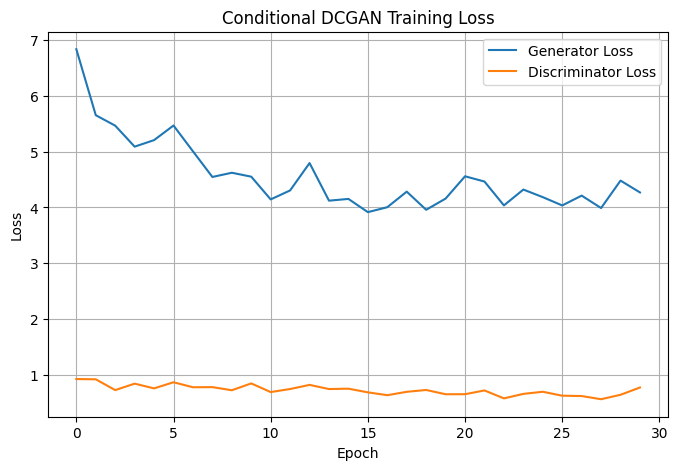

Saved loss curve: /kaggle/working/week6_cgan_safebooru/week6_loss_curve.png


In [26]:
plt.figure(figsize=(8, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conditional DCGAN Training Loss")
plt.legend()
plt.grid(True)

loss_path = f"{OUTPUT_DIR}/week6_loss_curve.png"
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved loss curve:", loss_path)

In [27]:
torch.save(generator.state_dict(), f"{OUTPUT_DIR}/models/conditional_dcgan_safebooru_generator.pth")
torch.save(discriminator.state_dict(), f"{OUTPUT_DIR}/models/conditional_dcgan_safebooru_discriminator.pth")

print("Models saved.")

Models saved.


In [28]:
generator.eval()

final_noise = torch.randn(num_classes * samples_per_class, latent_dim).to(device)

final_labels = []
for class_idx in range(num_classes):
    final_labels += [class_idx] * samples_per_class

final_labels = torch.tensor(final_labels, dtype=torch.long).to(device)

with torch.no_grad():
    final_images = generator(final_noise, final_labels)
    final_images = final_images * 0.5 + 0.5

final_grid = make_grid(final_images, nrow=samples_per_class)

final_path = f"{OUTPUT_DIR}/week6_final_samples.png"
save_image(final_grid, final_path)

print("Saved final samples:", final_path)

Saved final samples: /kaggle/working/week6_cgan_safebooru/week6_final_samples.png


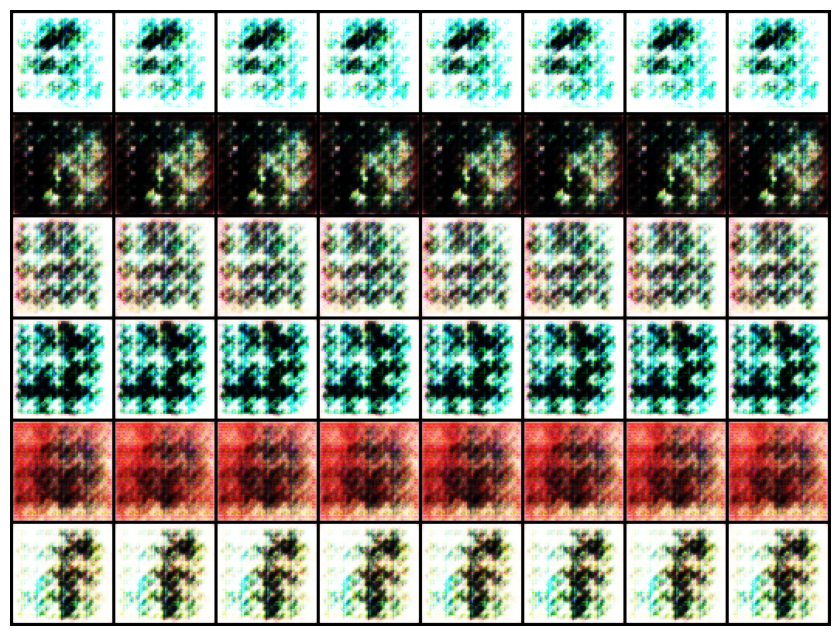

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/kaggle/working/week6_cgan_safebooru/week6_final_samples.png")

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()